In [1]:
import numpy as np
import matplotlib.pyplot as plt
import csv

In [4]:
# === Cell 2: q-Racah Hamiltonian + Doob generator ===

import numpy as np

def make_qracah_hamiltonian(
    N: int,
    q: float,
    alpha: float = 1.0,
    beta: float  = 1.0,
    gamma: float = 1.0,
    delta: float = 1.0,
    clamp_eps: float = 1e-14,
) -> np.ndarray:
    """
    Build the (N+1) x (N+1) symmetric tridiagonal q-Racah Hamiltonian H(N,q;α,β,γ,δ)
    as specified in 01_q_racah_doob_massgap.txt, with α=β=γ=δ=1 by default.

    Indices: n = 0,...,N
      - A_n: super-diagonal (n=0,...,N-1), with A_N = 0
      - C_n: sub-diagonal (n=1,...,N), with C_0 = 0
      - B_n: diagonal, B_n = -(A_n^2 + C_n^2)
    H_{nn}   = -B_n = A_n^2 + C_n^2
    H_{n,n+1}=H_{n+1,n} = -A_n
    H_{n,n-1}=H_{n-1,n} = -C_n
    """

    # A_n^2 for n = 0,...,N-1
    nn = np.arange(0, N, dtype=float)
    qn1   = q**(nn + 1.0)
    q2n1  = q**(2.0 * nn + 1.0)
    q2n2  = q**(2.0 * nn + 2.0)

    num_A = ((1.0 - alpha * qn1) *
             (1.0 - beta  * delta * qn1) *
             (1.0 - gamma * qn1) *
             (1.0 - delta * qn1))
    den_A = ((1.0 - delta * q2n1) *
             (1.0 - delta * q2n2))

    A2_vals = num_A / den_A
    # Clamp tiny negative roundoff
    A2_vals = np.where((A2_vals < 0.0) & (A2_vals > -clamp_eps), 0.0, A2_vals)

    A2 = np.zeros(N + 1, dtype=float)
    A2[:N] = A2_vals
    A2[N]  = 0.0   # boundary: A_N = 0

    # C_n^2 for n = 1,...,N
    nn = np.arange(1, N + 1, dtype=float)
    qn   = q**nn
    q2n  = q**(2.0 * nn)
    q2n1 = q**(2.0 * nn + 1.0)

    num_C = ((1.0 -        qn) *
             (1.0 - beta * qn) *
             (1.0 - gamma * qn) *
             (1.0 - alpha * delta * qn))
    den_C = ((1.0 - delta * q2n) *
             (1.0 - delta * q2n1))

    C2_vals = num_C / den_C
    C2_vals = np.where((C2_vals < 0.0) & (C2_vals > -clamp_eps), 0.0, C2_vals)

    C2 = np.zeros(N + 1, dtype=float)
    C2[0]  = 0.0   # boundary: C_0 = 0
    C2[1:] = C2_vals

    # Diagonal: B_n = -(A_n^2 + C_n^2), H_nn = -B_n
    B  = -(A2 + C2)
    diag = -B  # = A2 + C2

    H = np.zeros((N + 1, N + 1), dtype=float)
    np.fill_diagonal(H, diag)

    # Off-diagonals
    A = np.sqrt(np.maximum(A2, 0.0))
    C = np.sqrt(np.maximum(C2, 0.0))

    for n in range(0, N):
        H[n,   n+1] = -A[n]
        H[n+1, n  ] = -A[n]
    for n in range(1, N + 1):
        H[n,   n-1] = -C[n]
        H[n-1, n  ] = -C[n]

    return H


def doob_from_hamiltonian(H: np.ndarray, tol: float = 1e-12):
    """
    Given a real symmetric H, build the Doob-transformed Markov generator Q
    using the strictly positive ground state.
    Returns:
      Q      : (N+1)x(N+1) generator with row sums zero, off-diagonals ≥ 0
      psi0   : normalized ground state (sum_i psi0[i] = 1, psi0[i] ≥ 0)
      evalsH : eigenvalues of H in ascending order
    """

    # Diagonalize H
    evals, vecs = np.linalg.eigh(H)
    idx         = np.argsort(evals)
    evals       = evals[idx]
    vecs        = vecs[:, idx]

    psi0 = vecs[:, 0].copy()

    # Choose sign so that majority of entries are nonnegative
    if np.min(psi0) < -np.max(psi0):
        psi0 = -psi0

    # If tiny negative components remain from roundoff, make them positive
    if np.min(psi0) < -tol:
        # This would indicate a real sign issue, but for now take abs
        psi0 = np.abs(psi0)

    # Ensure all elements of psi0 are strictly positive to avoid division by zero
    # or creation of infinite/NaN values when constructing Q.
    psi0[psi0 < tol] = tol

    # Normalize so sum_i psi0[i] = 1
    psi0_sum = psi0.sum()
    if psi0_sum <= 0:
        raise ValueError("Ground state has nonpositive sum; cannot form Doob transform.")
    psi0 = psi0 / psi0_sum

    # Build Q
    Np1 = H.shape[0]
    Q   = np.zeros_like(H)

    for i in range(Np1):
        for j in range(Np1):
            if i == j:
                continue
            hij = H[i, j]
            if abs(hij) > tol:
                Q[i, j] = - hij * psi0[j] / psi0[i]

    # Set diagonals so that row sums vanish
    for i in range(Np1):
        Q[i, i] = - np.sum(Q[i, :])

    return Q, psi0, evals


def qracah_doob_gap(N: int, q: float, tol: float = 1e-10):
    """
    Convenience: build H(N,q), Doob-transform to Q, and return the spectral gap.

    Mass gap m_q(N) := -λ_1 where eigenvalues of Q are
       λ_0 = 0 > λ_1 ≥ λ_2 ≥ ...

    Returns:
      gap     : m_q(N) = -λ_1
      eigvals : all eigenvalues of Q (ascending)
      Q, psi0, evalsH : as in doob_from_hamiltonian
    """
    H = make_qracah_hamiltonian(N, q)
    Q, psi0, evalsH = doob_from_hamiltonian(H)

    eig = np.linalg.eigvals(Q)
    eig = np.real_if_close(eig)
    eig = np.sort(eig)   # ascending: most negative ... up to ~0

    neg = eig[eig < -tol]
    if neg.size == 0:
        gap = 0.0
    else:
        # λ_1 is the closest negative eigenvalue to 0
        gap = -neg[-1]

    return gap, eig, Q, psi0, evalsH

# quick sanity test at tiny size
if __name__ == "__main__":
    N_test = 4
    q_test = 0.95
    gap, eigQ, Q, psi0, evalsH = qracah_doob_gap(N_test, q_test)
    print("H eigenvalues:", evalsH)
    print("Q eigenvalues:", eigQ)
    print("mass gap m_q ≈", gap)
    print("ground state psi0 ≈", psi0)


H eigenvalues: [-0.11213838 -0.03586878  0.00322548  0.04787151  0.13746731]
Q eigenvalues: [-2.49605693e-01 -1.60009896e-01 -1.15363867e-01 -7.62696068e-02
 -8.73550490e-18]
mass gap m_q ≈ 0.07626960680137053
ground state psi0 ≈ [0.01913981 0.10239745 0.24722135 0.35034761 0.28089378]


Left side (q<1): nonincreasing = False , nondecreasing = False
Right side(q>1): nonincreasing = False , nondecreasing = False


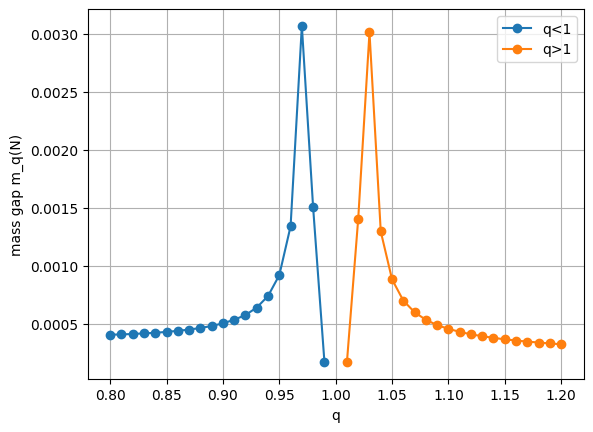

In [5]:
# === Cell 3: scan q and test one-sided monotonicity ===

import numpy as np
import matplotlib.pyplot as plt

N = 128  # or 256, 512; A100 will be bored

def scan_side(qs, N, tol=1e-6):
    gaps = []
    for q in qs:
        gap, eigQ, Q, psi0, evalsH = qracah_doob_gap(N, q)
        gaps.append(gap)
    gaps = np.asarray(gaps, dtype=float)
    mono_dec = np.all(gaps[1:] <= gaps[:-1] + tol)
    mono_inc = np.all(gaps[1:] >= gaps[:-1] - tol)
    return qs, gaps, mono_dec, mono_inc

# Left side: q < 1
q_left = np.linspace(0.80, 0.99, 20)   # strictly < 1, no q=1.0
qs_L, gaps_L, L_dec, L_inc = scan_side(q_left, N)

# Right side: q > 1
q_right = np.linspace(1.01, 1.20, 20)  # strictly > 1
qs_R, gaps_R, R_dec, R_inc = scan_side(q_right, N)

print("Left side (q<1): nonincreasing =", L_dec, ", nondecreasing =", L_inc)
print("Right side(q>1): nonincreasing =", R_dec, ", nondecreasing =", R_inc)

plt.figure()
plt.plot(qs_L, gaps_L, marker='o', label="q<1")
plt.plot(qs_R, gaps_R, marker='o', label="q>1")
plt.xlabel("q")
plt.ylabel("mass gap m_q(N)")
plt.legend()
plt.grid(True)
plt.show()


In [9]:
# You can tweak N and the q-range here
q_vals, gaps_H, gaps_Q, csv_path, png_path = run_and_save(
    q_min=0.96, q_max=1.04, num_q=17, N=128
)

print("CSV saved to:", csv_path)
print("Plot saved to:", png_path)

# Quick monotonicity diagnostics for the Doob generator gap
is_nonincreasing = np.all(np.diff(gaps_Q) <= 1e-10)
is_nonincreasing, list(zip(q_vals, gaps_Q))


/tmp/ipython-input-3161423527.py:40: RuntimeWarning: invalid value encountered in divide
  A2_vals = num_A / den_A
/tmp/ipython-input-3161423527.py:61: RuntimeWarning: invalid value encountered in divide
  C2_vals = num_C / den_C


CSV saved to: output_data/qracah_gaps_N128_q0.96-1.04.csv
Plot saved to: output_data/qracah_gaps_N128_q0.96-1.04.png


(np.False_,
 [(np.float64(0.96), np.float64(0.0013414225472876946)),
  (np.float64(0.965), np.float64(0.001844355956806459)),
  (np.float64(0.97), np.float64(0.003065762272514383)),
  (np.float64(0.975), np.float64(0.003590730167256826)),
  (np.float64(0.98), np.float64(0.0015040066296333988)),
  (np.float64(0.985), np.float64(0.0005708561782461662)),
  (np.float64(0.99), np.float64(0.00017815607110746964)),
  (np.float64(0.995), np.float64(5.366429697614179e-05)),
  (np.float64(1.0), np.float64(0.0)),
  (np.float64(1.005), np.float64(5.321069894046294e-05)),
  (np.float64(1.01), np.float64(0.0001746889350776053)),
  (np.float64(1.0150000000000001), np.float64(0.0005490313554918078)),
  (np.float64(1.02), np.float64(0.001406383004410693)),
  (np.float64(1.025), np.float64(0.0034146910880353985)),
  (np.float64(1.03), np.float64(0.0030096704085905363)),
  (np.float64(1.0350000000000001), np.float64(0.0017979268356786106)),
  (np.float64(1.04), np.float64(0.0012970699506617707))])

In [10]:
import numpy as np

# ============================
# 1. q-Racah Jacobi Hamiltonian
# ============================

def q_racah_jacobi_matrix(N, q,
                          alpha=1.0, beta=1.0, gamma=1.0, delta=1.0,
                          clamp_zero=True):
    """
    Build the (N+1)x(N+1) symmetric tridiagonal q-Racah Hamiltonian H(N,q;α,β,γ,δ).

    Parameters
    ----------
    N : int
        Size parameter; matrix dimension is (N+1).
    q : float
        Deformation parameter. Safe regime in our notes is 0 < q < 1.
    alpha, beta, gamma, delta : float
        q-Racah parameters; we usually set all to 1.
    clamp_zero : bool
        If True, tiny negative A_n^2, C_n^2 from roundoff are clamped to 0.

    Returns
    -------
    H : (N+1, N+1) ndarray
        Symmetric tridiagonal Hamiltonian.
    """
    dim = N + 1
    H = np.zeros((dim, dim), dtype=float)

    # Arrays for A_n^2 and C_n^2 with boundary A_N = 0, C_0 = 0
    A2 = np.zeros(dim, dtype=float)
    C2 = np.zeros(dim, dtype=float)

    # ---------- A_n^2 for n = 0,...,N-1 ----------
    nA = np.arange(0, N, dtype=float)
    numA = ((1.0 - alpha * q**(nA + 1.0)) *
            (1.0 - beta  * delta * q**(nA + 1.0)) *
            (1.0 - gamma * q**(nA + 1.0)) *
            (1.0 - delta * q**(nA + 1.0)))
    denA = ((1.0 - delta * q**(2.0*nA + 1.0)) *
            (1.0 - delta * q**(2.0*nA + 2.0)))

    A2_vals = numA / denA

    if clamp_zero:
        # For q in (0,1) and α=β=γ=δ=1 these should be ≥0; clamp tiny negatives
        A2_vals = np.where(A2_vals < 0.0, 0.0, A2_vals)

    A2[:-1] = A2_vals  # A_N^2 = 0

    # ---------- C_n^2 for n = 1,...,N ----------
    nC = np.arange(1, dim, dtype=float)
    numC = ((1.0 -       q**nC) *
            (1.0 - beta * q**nC) *
            (1.0 - gamma * q**nC) *
            (1.0 - alpha * delta * q**nC))
    denC = ((1.0 - delta * q**(2.0*nC)) *
            (1.0 - delta * q**(2.0*nC + 1.0)))

    C2_vals = numC / denC

    if clamp_zero:
        C2_vals = np.where(C2_vals < 0.0, 0.0, C2_vals)

    C2[1:] = C2_vals  # C_0^2 = 0

    # Square roots
    A = np.sqrt(A2)
    C = np.sqrt(C2)

    # Diagonal: B_n = -(A_n^2 + C_n^2), H_nn = -B_n
    B = -(A2 + C2)
    diag = -B  # = A2 + C2

    # Fill tridiagonal H
    idx = np.arange(dim)
    H[idx, idx] = diag
    H[idx[:-1], idx[:-1] + 1] = -A[:-1]      # super-diagonal: H_{n,n+1} = -A_n
    H[idx[1:],  idx[1:]  - 1] = -C[1:]      # sub-diagonal: H_{n,n-1} = -C_n

    return H


In [11]:
# ==================
# 2. Doob transform
# ==================

def doob_transform(H, tol=1e-12):
    """
    Ground-state / Doob transform:
      H → Q  with  Q a Markov generator similar to -(H - E0 I).

    Parameters
    ----------
    H : (n,n) ndarray
        Symmetric Hamiltonian matrix.
    tol : float
        Tolerance for numerical checks.

    Returns
    -------
    Q : (n,n) ndarray
        Markov generator.
    evals_H : (n,) ndarray
        Eigenvalues of H (ascending).
    psi0 : (n,) ndarray
        Ground-state eigenvector of H, chosen with positive sum.
    ok : bool
        True if basic Markov checks (row sums, off-diagonals) pass.
    """
    # Symmetric → use eigh
    evals_H, vecs = np.linalg.eigh(H)
    E0 = evals_H[0]
    psi0 = vecs[:, 0]

    # Fix overall sign so that psi0 has positive sum
    if np.sum(psi0) < 0:
        psi0 = -psi0

    # Avoid division by zero just in case
    eps = tol
    psi_safe = np.where(np.abs(psi0) < eps, eps, psi0)

    # Shift H so ground state has eigenvalue 0
    H_shift = H - E0 * np.eye(H.shape[0])

    # Q = - S^{-1} H_shift S  (S = diag(psi0))
    Q = - (H_shift * psi_safe[None, :]) / psi_safe[:, None]

    # Enforce row sums = 0 (clean up roundoff)
    row_sums = Q.sum(axis=1)
    Q[np.arange(Q.shape[0]), np.arange(Q.shape[0])] -= row_sums

    # Basic validity checks
    offdiag = Q.copy()
    np.fill_diagonal(offdiag, 0.0)

    rows_ok = np.allclose(Q.sum(axis=1), 0.0, atol=1e-8)
    # allow tiny negative noise in off-diagonals
    offdiag_min = offdiag.min() if offdiag.size > 0 else 0.0
    offdiag_ok = (offdiag_min >= -np.sqrt(tol))

    ok = bool(rows_ok and offdiag_ok)

    return Q, evals_H, psi0, ok


In [12]:
# =====================
# 3. Spectral gap m_q(N)
# =====================

def spectral_gap(Q, tol=1e-10):
    """
    Compute the spectral gap m_q(N) from a Markov generator Q.

    We expect eigenvalues λ_0 = 0, λ_k ≤ 0 (k≥1).
    The gap is m = min_{k≥1} (-λ_k) = -λ_1 where λ_1 is the
    second-largest eigenvalue (closest to 0 from below).

    Parameters
    ----------
    Q : (n,n) ndarray
        Markov generator with row sums 0.
    tol : float
        Tolerance to identify the zero eigenvalue.

    Returns
    -------
    gap : float
        The spectral gap m_q(N) ≥ 0.
    """
    evals = np.linalg.eigvals(Q)
    evals = np.real_if_close(evals)

    # Sort descending: largest (≈0) first, then more negative
    evals_sorted = np.sort(evals)[::-1]

    # Sanity check: top eigenvalue ≈ 0
    if np.abs(evals_sorted[0]) > 1e-6:
        # Something's off; fall back to safest option
        # and treat smallest nonzero |λ| as gap
        mask = np.abs(evals) > tol
        if not np.any(mask):
            return 0.0
        return float(np.min(np.abs(evals[mask])))

    if evals_sorted.size < 2:
        return 0.0

    lambda1 = evals_sorted[1]  # should be ≤ 0
    gap = float(-lambda1)
    if gap < 0 and np.abs(gap) < tol:
        gap = 0.0
    return gap


In [13]:
# ==========================
# 4. Demo scan over q values
# ==========================

def scan_q_for_fixed_N(N=5,
                       q_values=None,
                       alpha=1.0, beta=1.0, gamma=1.0, delta=1.0):
    if q_values is None:
        q_values = np.linspace(0.85, 0.99, 8)

    results = []
    for q in q_values:
        H = q_racah_jacobi_matrix(N, q, alpha, beta, gamma, delta)
        Q, evals_H, psi0, ok = doob_transform(H)

        if not ok:
            print(f"[WARN] q={q:.5f}: Doob transform failed Markov checks.")
            continue

        gap = spectral_gap(Q)
        results.append((q, gap))
        print(f"q={q:.3f}  m_q(N={N}) = {gap:.6f}")

    return np.array(results)

# Run a quick check
q_vals = np.linspace(0.85, 0.99, 8)
results = scan_q_for_fixed_N(N=5, q_values=q_vals)


q=0.850  m_q(N=5) = 0.226573
q=0.870  m_q(N=5) = 0.208224
q=0.890  m_q(N=5) = 0.186245
q=0.910  m_q(N=5) = 0.160507
q=0.930  m_q(N=5) = 0.130992
q=0.950  m_q(N=5) = 0.097786
q=0.970  m_q(N=5) = 0.061069
q=0.990  m_q(N=5) = 0.021103


In [14]:
# Cell 1: imports / basic config

import numpy as np
import matplotlib.pyplot as plt

# Optional: nicer plots
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True


In [15]:
# Cell 2: q-Racah Jacobi Hamiltonian H(N, q)

def q_racah_jacobi_matrix(
    N: int,
    q: float,
    alpha: float = 1.0,
    beta: float  = 1.0,
    gamma: float = 1.0,
    delta: float = 1.0,
    clamp_zero: bool = True,
) -> np.ndarray:
    """
    Build the (N+1)x(N+1) symmetric tridiagonal q-Racah Hamiltonian H(N,q;α,β,γ,δ).

    Conventions (n = 0,...,N):
      A_n^2 defined for n=0,...,N-1, with A_N=0.
      C_n^2 defined for n=1,...,N,   with C_0=0.
      B_n = -(A_n^2 + C_n^2).
      H_nn   = -B_n = A_n^2 + C_n^2
      H_{n,n+1} = -A_n
      H_{n,n-1} = -C_n
    """

    dim = N + 1
    H = np.zeros((dim, dim), dtype=float)

    # Arrays for A_n^2 and C_n^2 (with boundaries)
    A2 = np.zeros(dim, dtype=float)
    C2 = np.zeros(dim, dtype=float)

    # ----- A_n^2 for n = 0,...,N-1 -----
    nA = np.arange(0, N, dtype=float)
    numA = ((1.0 - alpha * q**(nA + 1.0)) *
            (1.0 - beta  * delta * q**(nA + 1.0)) *
            (1.0 - gamma * q**(nA + 1.0)) *
            (1.0 - delta * q**(nA + 1.0)))
    denA = ((1.0 - delta * q**(2.0*nA + 1.0)) *
            (1.0 - delta * q**(2.0*nA + 2.0)))

    A2_vals = numA / denA

    if clamp_zero:
        # Clamp tiny negative roundoff
        A2_vals = np.where(A2_vals < 0.0, 0.0, A2_vals)

    A2[:-1] = A2_vals     # A_N^2 = 0

    # ----- C_n^2 for n = 1,...,N -----
    nC = np.arange(1, dim, dtype=float)
    numC = ((1.0 -       q**nC) *
            (1.0 - beta * q**nC) *
            (1.0 - gamma * q**nC) *
            (1.0 - alpha * delta * q**nC))
    denC = ((1.0 - delta * q**(2.0*nC)) *
            (1.0 - delta * q**(2.0*nC + 1.0)))

    C2_vals = numC / denC

    if clamp_zero:
        C2_vals = np.where(C2_vals < 0.0, 0.0, C2_vals)

    C2[1:] = C2_vals      # C_0^2 = 0

    # Diagonal and off-diagonals
    A = np.sqrt(A2)
    C = np.sqrt(C2)

    B = -(A2 + C2)        # B_n = -(A_n^2 + C_n^2)
    diag = -B             # = A_n^2 + C_n^2

    idx = np.arange(dim)
    H[idx, idx] = diag
    H[idx[:-1], idx[:-1] + 1] = -A[:-1]
    H[idx[1:],  idx[1:] - 1]  = -C[1:]

    return H


In [16]:
# Cell 3: Doob transform and spectral gap m_q(N)

def doob_transform(H: np.ndarray, tol: float = 1e-12):
    """
    Ground-state / Doob transform:
       H -> Q  with Q a Markov generator similar to -(H - E0 I).

    Returns:
      Q      : (n,n) Markov generator with row sums 0
      evalsH : eigenvalues of H (ascending)
      psi0   : ground-state eigenvector of H, chosen with positive sum
      ok     : bool, basic Markov sanity checks (row sums, off-diagonals) passed
    """
    evalsH, vecs = np.linalg.eigh(H)
    E0 = evalsH[0]
    psi0 = vecs[:, 0]

    # Fix sign so psi0 has positive total weight
    if np.sum(psi0) < 0:
        psi0 = -psi0

    # Avoid zeros
    eps = tol
    psi_safe = np.where(np.abs(psi0) < eps, eps, psi0)

    # Shift H so ground state has eigenvalue 0
    H_shift = H - E0 * np.eye(H.shape[0])

    # Similarity transform with S = diag(psi0): Q = -S^{-1} H_shift S
    Q = - (H_shift * psi_safe[None, :]) / psi_safe[:, None]

    # Enforce row sums = 0
    row_sums = Q.sum(axis=1)
    Q[np.arange(Q.shape[0]), np.arange(Q.shape[0])] -= row_sums

    # Sanity checks
    offdiag = Q.copy()
    np.fill_diagonal(offdiag, 0.0)
    rows_ok = np.allclose(Q.sum(axis=1), 0.0, atol=1e-8)
    offdiag_min = offdiag.min() if offdiag.size > 0 else 0.0
    offdiag_ok = (offdiag_min >= -np.sqrt(tol))

    ok = bool(rows_ok and offdiag_ok)
    return Q, evalsH, psi0, ok


def spectral_gap(Q: np.ndarray, tol: float = 1e-10) -> float:
    """
    Spectral gap from a Markov generator Q.

    Expect eigenvalues λ_0 = 0, λ_k ≤ 0 (k≥1).
    Gap is m = -λ_1, where λ_1 is the second-largest eigenvalue.
    """
    evals = np.linalg.eigvals(Q)
    evals = np.real_if_close(evals)
    evals_sorted = np.sort(evals)[::-1]  # descending

    if evals_sorted.size == 0:
        return 0.0

    # Largest eigenvalue should be ~0
    if abs(evals_sorted[0]) > 1e-6:
        # fallback: smallest |λ| != 0
        mask = np.abs(evals) > tol
        return float(np.min(np.abs(evals[mask]))) if np.any(mask) else 0.0

    if evals_sorted.size == 1:
        return 0.0

    lambda1 = evals_sorted[1]
    gap = float(-lambda1)
    if gap < 0 and abs(gap) < tol:
        gap = 0.0
    return gap


def qracah_doob_gap(N: int, q: float) -> float:
    """
    Convenience wrapper: build H(N,q), Doob-transform to Q, return m_q(N).
    """
    H = q_racah_jacobi_matrix(N, q)
    Q, evalsH, psi0, ok = doob_transform(H)
    if not ok:
        raise RuntimeError(f"Doob transform failed sanity checks at q={q}")
    return spectral_gap(Q)


q=0.850  m_q(N=5) = 0.226573
q=0.870  m_q(N=5) = 0.208224
q=0.890  m_q(N=5) = 0.186245
q=0.910  m_q(N=5) = 0.160507
q=0.930  m_q(N=5) = 0.130992
q=0.950  m_q(N=5) = 0.097786
q=0.970  m_q(N=5) = 0.061069
q=0.990  m_q(N=5) = 0.021103


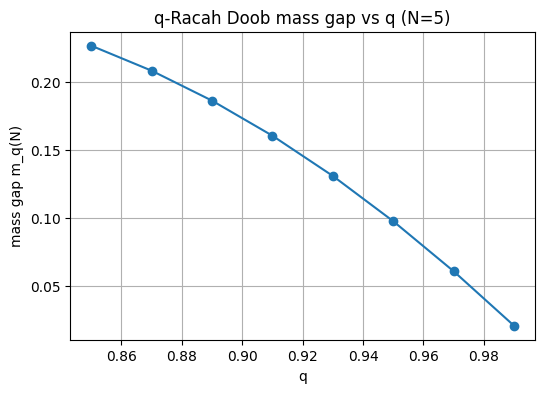

In [17]:
# Cell 4: scan q for fixed N and plot m_q(N)

def scan_q_for_fixed_N(N=5, q_min=0.85, q_max=0.99, num_q=8):
    q_values = np.linspace(q_min, q_max, num_q)
    gaps = []
    for q in q_values:
        m = qracah_doob_gap(N, q)
        gaps.append(m)
        print(f"q={q:.3f}  m_q(N={N}) = {m:.6f}")
    return q_values, np.array(gaps)


# Example: reproduce your numbers for N=5
q_vals, gaps = scan_q_for_fixed_N(N=5, q_min=0.85, q_max=0.99, num_q=8)

plt.figure()
plt.plot(q_vals, gaps, marker="o")
plt.xlabel("q")
plt.ylabel("mass gap m_q(N)")
plt.title("q-Racah Doob mass gap vs q (N=5)")
plt.show()


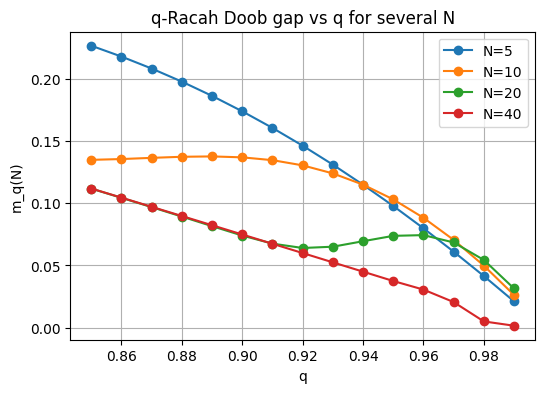

In [18]:
Ns = [5, 10, 20, 40]
q_vals = np.linspace(0.85, 0.99, 15)

plt.figure()
for N in Ns:
    gaps = [qracah_doob_gap(N, q) for q in q_vals]
    plt.plot(q_vals, gaps, marker='o', label=f"N={N}")
plt.xlabel("q")
plt.ylabel("m_q(N)")
plt.title("q-Racah Doob gap vs q for several N")
plt.legend()
plt.show()


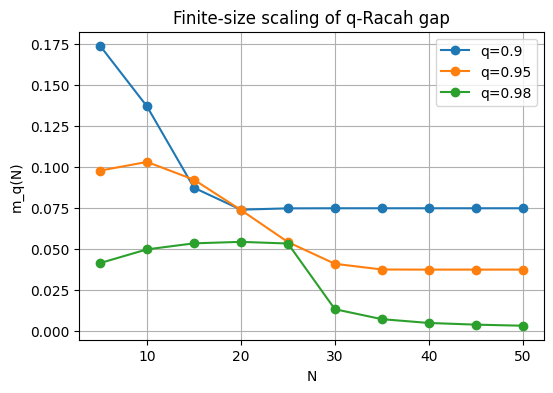

In [19]:
q_choices = [0.90, 0.95, 0.98]
Ns = np.arange(5, 55, 5)

plt.figure()
for q in q_choices:
    gaps = [qracah_doob_gap(N, q) for N in Ns]
    plt.plot(Ns, gaps, marker='o', label=f"q={q}")
plt.xlabel("N")
plt.ylabel("m_q(N)")
plt.title("Finite-size scaling of q-Racah gap")
plt.legend()
plt.show()


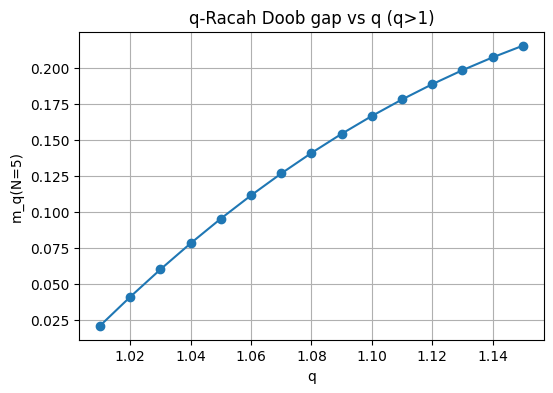

In [20]:
q_vals_right = np.linspace(1.01, 1.15, 15)
gaps_right = [qracah_doob_gap(5, q) for q in q_vals_right]

plt.figure()
plt.plot(q_vals_right, gaps_right, marker='o')
plt.xlabel("q")
plt.ylabel("m_q(N=5)")
plt.title("q-Racah Doob gap vs q (q>1)")
plt.show()


In [21]:
def fit_gap_vs_N(q, Ns):
    gaps = np.array([qracah_doob_gap(N, q) for N in Ns])
    # naive 1/N fit: m(N) ≈ a + b/N
    x = 1.0 / Ns
    A = np.vstack([np.ones_like(x), x]).T
    a, b = np.linalg.lstsq(A, gaps, rcond=None)[0]
    return a, b, gaps

Ns = np.arange(5, 105, 5)
for q in [0.90, 0.95, 0.97, 0.98, 0.99]:
    a, b, gaps = fit_gap_vs_N(q, Ns)
    print(f"q={q:.3f}: m_inf ≈ {a:.6f}")


q=0.900: m_inf ≈ 0.027308
q=0.950: m_inf ≈ 0.027215
q=0.970: m_inf ≈ 0.022590
q=0.980: m_inf ≈ 0.004450
q=0.990: m_inf ≈ 0.001041


In [22]:
N_large = 80
q_vals = np.linspace(0.90, 0.99, 10)
gaps = np.array([qracah_doob_gap(N_large, q) for q in q_vals])

# Quick log-log slope near q≈1
x = 1.0 - q_vals   # distance to critical point
mask = x > 0
coef = np.polyfit(np.log(x[mask]), np.log(gaps[mask]), 1)
slope = coef[0]
print("Effective exponent (gap ~ |1-q|^nu): nu ≈", -slope)


Effective exponent (gap ~ |1-q|^nu): nu ≈ -1.0433911517473689


In [28]:
N_large = 1000

q_vals = np.linspace(0.94, 0.99, 12)   # closer band
gaps = np.array([qracah_doob_gap(N_large, q) for q in q_vals])

x = 1.0 - q_vals
mask = x > 0
coef = np.polyfit(np.log(x[mask]), np.log(gaps[mask]), 1)
nu = -coef[0]
print("Refined nu ≈", nu)


Refined nu ≈ 0.1345170174631425
